# **Preprocesamiento de imágenes**

## **Librerías y modlulos necesarios**

In [ ]:
import os
import cv2
import numpy as np
from glob import glob
import matplotlib.pyplot as plt

## **Carge de imágenes**

Inicialmente, se cargaron las imágenes previamente utilizadas, las cuales incluyen las nuevas observaciones tanto en las máscaras como en las imágenes.

In [ ]:
data_path = "/content/drive/MyDrive/PF/imagenes" # Ruta a la carpeta donde están las imágenes
paths = os.listdir(data_path)
print(f"La clase 'normal' tiene {len([i for i in paths if i.startswith('normal') and 'mask' not in i])} imágenes y {len([i for i in paths if i.startswith('normal') and 'mask' in i])} máscaras.")
print(f"La clase 'benigno' tiene {len([i for i in paths if i.startswith('benigno') and 'mask' not in i])} imágenes y {len([i for i in paths if i.startswith('benigno') and 'mask' in i])} máscaras.")
print(f"La clase 'maligno' tiene {len([i for i in paths if i.startswith('maligno') and 'mask' not in i])} imágenes y {len([i for i in paths if i.startswith('maligno') and 'mask' in i])} máscaras.")
print(f"\nEn total hay {len([i for i in paths if 'mask' not in i])} imágenes y {len([i for i in paths if 'mask' in i])} máscaras.")

La clase 'normal' tiene 133 imágenes y 133 máscaras.
La clase 'benigno' tiene 454 imágenes y 454 máscaras.
La clase 'maligno' tiene 211 imágenes y 211 máscaras.

En total hay 798 imágenes y 798 máscaras.


## **Función para el procesamiento**

La función `cargar_datos` permite la lectura y preprocesamiento de las imágenes médicas utilizadas en la segmentación de tumores en ultrasonidos de cáncer de mama. Organiza las imágenes en dos categorías: aquellas que contienen estructuras tumorales (benignas o malignas) y las normales, diferenciando también sus respectivas máscaras. Para cada imagen, busca la máscara correspondiente y, si no la encuentra, asigna una máscara vacía. Además, convierte las imágenes a escala de grises, las normaliza y las redimensiona al tamaño especificado, garantizando un formato uniforme para su posterior uso en modelos de deep learning.

In [ ]:
def cargar_imagen(ruta, tamaño = 128):
    img = cv2.imread(ruta, cv2.IMREAD_COLOR)  # Cargar en color
    img = cv2.resize(img, (tamaño, tamaño))   # Redimensionar
    img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)  # Convertir a escala de grises
    img = img / 255.0  # Normalizar (0-1)
    return img

def cargar_datos(ruta_base, tamaño=128):
    imagenes = []       # Lista de imágenes benignas/malignas
    normales = []       # Lista de imágenes normales
    mascaras = []       # Lista de máscaras benignas/malignas
    mascaras_normales = []  # Lista de máscaras normales

    archivos_imagen = sorted(glob(os.path.join(ruta_base, "*.png")))

    for ruta in archivos_imagen:
        if "mask" in ruta.lower():
            continue  # Saltar las máscaras en este paso

        img = cargar_imagen(ruta, tamaño)  # Cargar imagen

        # Buscar la máscara correspondiente
        nombre_base = os.path.basename(ruta).replace(".png", "")  # Quitar extensión
        ruta_mascara = os.path.join(ruta_base, f"{nombre_base}_mask.png")

        if "normal" in ruta.lower():
            normales.append(img)  # Agregar imagen normal

            # Cargar máscara si existe
            if os.path.exists(ruta_mascara):
                mascaras_normales.append(cargar_imagen(ruta_mascara, tamaño))
            else:
                mascaras_normales.append(np.zeros((tamaño, tamaño)))  # Máscara vacía si no existe
        else:
            imagenes.append(img)  # Agregar imagen de benigno/maligno

            # Cargar máscara si existe
            if os.path.exists(ruta_mascara):
                mascaras.append(cargar_imagen(ruta_mascara, tamaño))
            else:
                mascaras.append(np.zeros((tamaño, tamaño)))  # Máscara vacía si no existe

    print(f"Cargadas {len(imagenes)} imágenes (benigno/maligno), {len(normales)} normales, "
          f"{len(mascaras)} máscaras (benigno/maligno) y {len(mascaras_normales)} máscaras normales.")

    return np.array(imagenes), np.array(normales), np.array(mascaras), np.array(mascaras_normales)


## **Preprocesamiento aplicando la función**

Cargamos los datos con la función anteriormente definida.

In [ ]:
X, X_normal, y, y_normal = cargar_datos(data_path)

Cargadas 665 imágenes (benigno/maligno), 133 normales, 665 máscaras (benigno/maligno) y 133 máscaras normales.


Guardamos la información en arreglos de `numpy` para evitar repetir el preprocesamiento cada vez que se implemente una nueva arquitectura, optimizando así el tiempo de ejecución y facilitando la reutilización de los datos preprocesados.

In [ ]:
np.save("imagenes_cancer.npy", X)
np.save("mascaras_cancer.npy", y)
np.save("imagenes_normal.npy", X_normal)
np.save("mascaras_normal.npy", y_normal)

In [ ]:
X = np.load("imagenes_cancer.npy")
y = np.load("mascaras_cancer.npy")

## **Visualización de imágenes**

Finalmente, mostramos una serie de imágenes representativas de cada categoría (normal, benigna y maligna) junto con sus respectivas máscaras y superposiciones. Esto nos permite verificar visualmente que los datos han sido correctamente preprocesados y están listos para la implementación de las diferentes arquitecturas de segmentación.

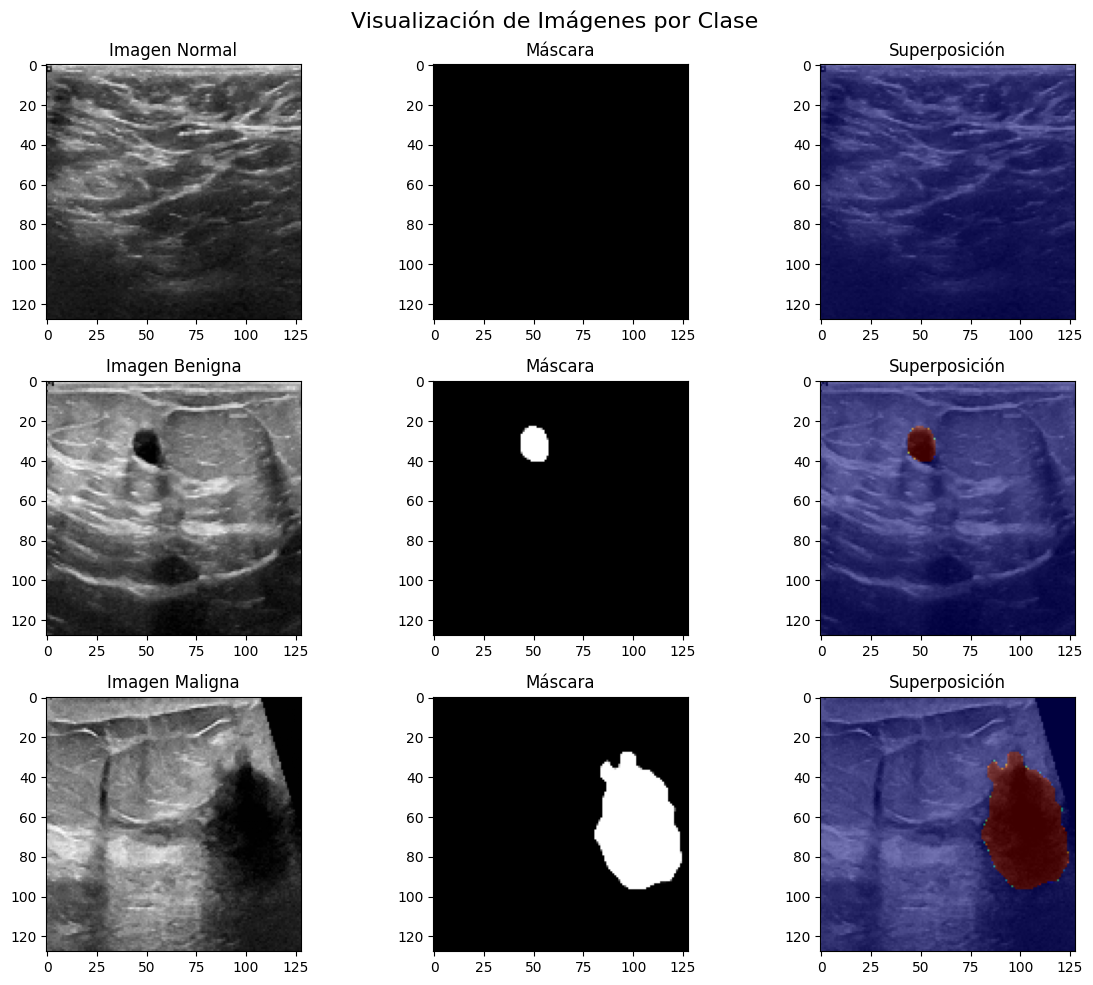

In [ ]:
idx_normal = np.random.randint(0, len(X_normal))
idx_benigno = np.random.randint(0, 454)  # Dentro del rango de imágenes benignas
idx_maligno = np.random.randint(454, 665)  # Dentro del rango de imágenes malignas

fig, ax = plt.subplots(3, 3, figsize=(12, 10))

ax[0, 0].imshow(X_normal[idx_normal], cmap='gray')
ax[0, 0].set_title('Imagen Normal')
ax[0, 1].imshow(y_normal[idx_normal], cmap='gray')
ax[0, 1].set_title('Máscara')
ax[0, 2].imshow(X_normal[idx_normal], cmap='gray')
ax[0, 2].imshow(tf.squeeze(y_normal[idx_normal]), alpha=0.5, cmap='jet')
ax[0, 2].set_title('Superposición')

ax[1, 0].imshow(X[idx_benigno], cmap='gray')
ax[1, 0].set_title('Imagen Benigna')
ax[1, 1].imshow(y[idx_benigno], cmap='gray')
ax[1, 1].set_title('Máscara')
ax[1, 2].imshow(X[idx_benigno], cmap='gray')
ax[1, 2].imshow(tf.squeeze(y[idx_benigno]), alpha=0.5, cmap='jet')
ax[1, 2].set_title('Superposición')

ax[2, 0].imshow(X[idx_maligno], cmap='gray')
ax[2, 0].set_title('Imagen Maligna')
ax[2, 1].imshow(y[idx_maligno], cmap='gray')
ax[2, 1].set_title('Máscara')
ax[2, 2].imshow(X[idx_maligno], cmap='gray')
ax[2, 2].imshow(tf.squeeze(y[idx_maligno]), alpha=0.5, cmap='jet')
ax[2, 2].set_title('Superposición')

fig.suptitle('Visualización de Imágenes por Clase', fontsize=16)
plt.tight_layout()
plt.show()
